In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sessions = pd.read_csv("../data/sessions.csv")

## Exploratory Data Analysis

This notebook explores session-level behavioral patterns to understand which engagement signals are associated with purchase conversion

### Session Engagement Summary

Basic behavioral metrics describing how users interact with the platform during a session

In [ ]:
avg_events = sessions["total_events"].mean()
avg_duration = sessions["session_duration"].mean()
avg_num_views = sessions["num_views"].mean()
pct_cart = sessions["has_cart"].mean() * 100 

avg_events, avg_duration, avg_num_views, pct_cart

(np.float64(4.4655312977168),
 np.float64(2148.922702724615),
 np.float64(1.9913113196074104),
 np.float64(38.754937773914136))

### Funnel Structure

In [ ]:
conversion_rate = sessions["converted"].mean() * 100

cart_conversion = (
    sessions[sessions["has_cart"]]["converted"].mean() * 100
)

non_cart_conversion = (
    sessions[sessions["has_cart"] == 0]["converted"].mean() * 100
)

pct_view = (sessions["num_views"] > 0).mean() * 100
pct_add_cart = (sessions["num_add_cart"] > 0).mean() * 100
pct_num_purchase = (sessions["num_purchase"] > 0).mean() * 100

cart_to_purchase_conversion = sessions[sessions["has_cart"]]["converted"].mean() * 100

pd.Series({
    "Overall conversion rate (%)": conversion_rate,
    "Conversion with cart (%)": cart_conversion,
    "Conversion without cart (%)": non_cart_conversion,
    "Sessions with atleast one view (%)": pct_view,
    "Sessions with atleast one add to cart (%)": pct_add_cart,
    "Sessions with atleast one purchase (%)": pct_num_purchase,
    "Cart to purchase conversion rate (%)": cart_to_purchase_conversion
})

Overall conversion rate (%)                   3.005680
Conversion with cart (%)                      6.443440
Conversion without cart (%)                   0.830318
Sessions with atleast one view (%)           95.282709
Sessions with atleast one add to cart (%)    38.754938
Sessions with atleast one purchase (%)        3.005680
Cart to purchase conversion rate (%)          6.443440
dtype: float64

### Revenue Metrics

In [ ]:
avg_order_value = sessions[sessions["converted"] == 1]["session_revenue"].mean()

revenue_per_session = sessions["session_revenue"].mean()

total_revenue = sessions["session_revenue"].sum()

pd.Series({
    "Average order value ($)": avg_order_value,
    "Revenue per session ($)": revenue_per_session,
    "Total revenue ($)": total_revenue
})

Average order value ($)        41.103038
Revenue per session ($)         1.235426
Total revenue ($)          274280.570000
dtype: float64

### Behavioral Differences Between Converting and Non-Converting Sessions

In [ ]:
# Compare behaviors between converted (1) and non-converted (0)

behavior_summary = sessions.groupby("converted")[[
    "total_events",
    "num_views",
    "session_duration",
    "avg_view_price",
    "max_view_price",
    "num_add_cart"
]].mean()

behavior_summary

,total_events,num_views,session_duration,avg_view_price,max_view_price,num_add_cart
converted,,,,,,
0,3.777101,1.854003,1882.309306,12.813303,14.883240,1.460597
1,26.681403,6.422299,10752.628503,7.561676,17.392695,7.470403


<Axes: xlabel='converted', ylabel='total_events'>

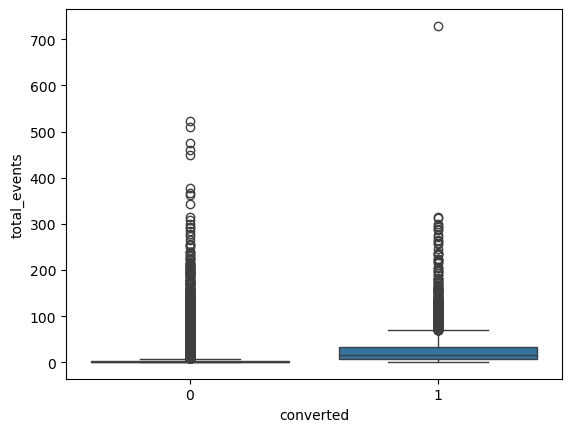

In [ ]:
sns.boxplot(x = "converted", y = "total_events", data = sessions)

In [ ]:
sessions.groupby("converted")["session_duration"].median()

converted
0       0.0
1    1021.0
Name: session_duration, dtype: float64

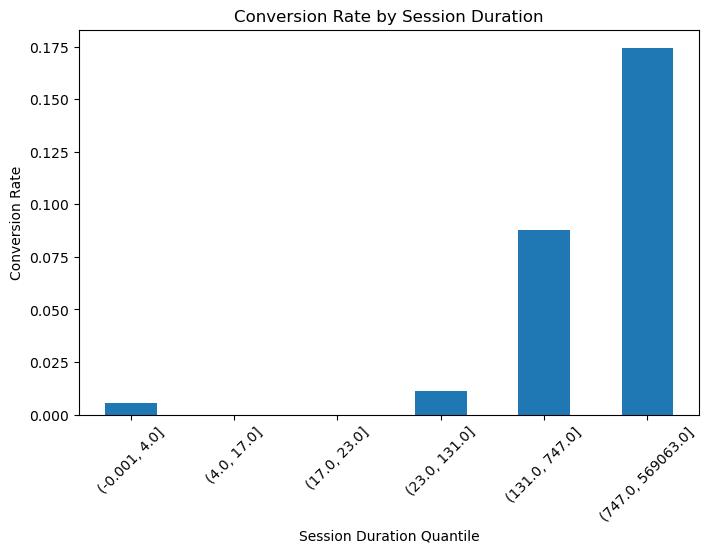

In [ ]:
sessions["duration_bin"] = pd.qcut(sessions["session_duration"], 10, duplicates = "drop")

duration_conv = sessions.groupby("duration_bin")["converted"].mean()

duration_conv.plot(kind="bar", figsize=(8,5))
plt.title("Conversion Rate by Session Duration")
plt.ylabel("Conversion Rate")
plt.xlabel("Session Duration Quantile")
plt.xticks(rotation = 45)
plt.show()

In [ ]:
# calculate lift
mean_conv = sessions[sessions["converted"] == 1]["num_views"].mean()
mean_non = sessions[sessions["converted"] == 0]["num_views"].mean()

lift = mean_conv / mean_non
lift

np.float64(3.4640175409446647)